In [53]:
import pandas as pd
from utils.plot_utils import *


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

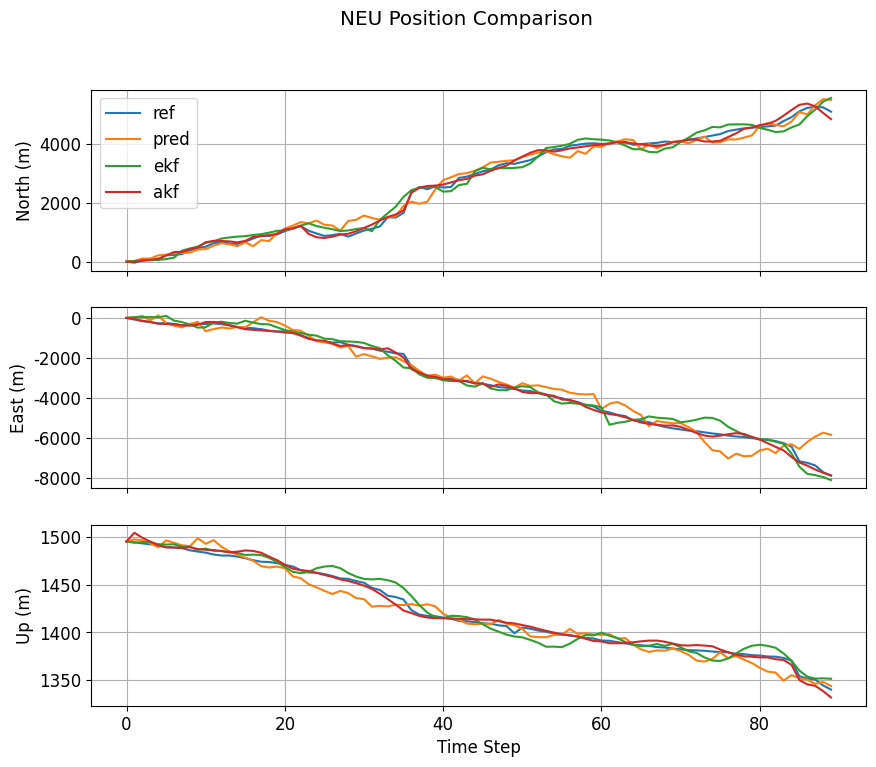

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

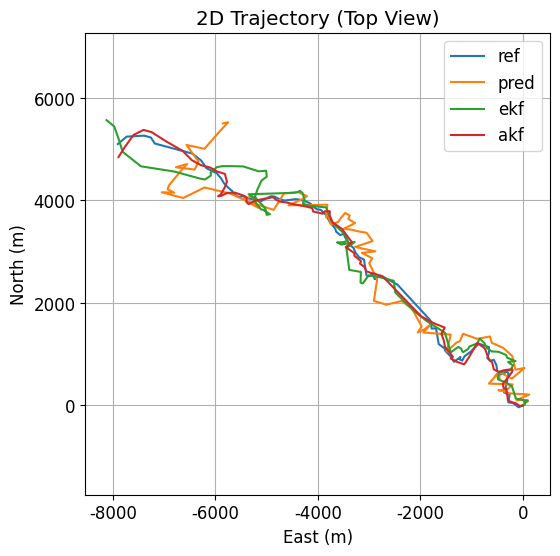

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

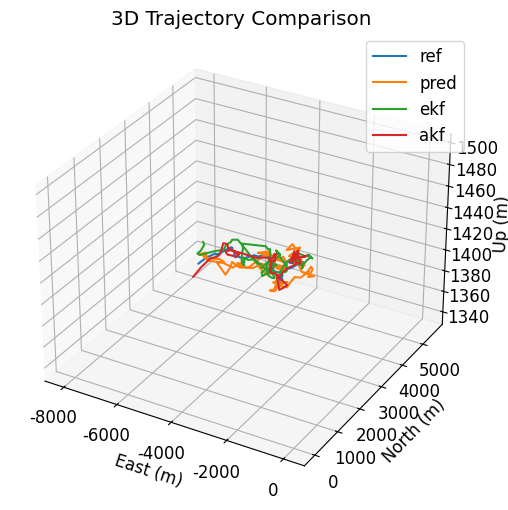

In [54]:
# 原始数据

dfs = pd.read_excel("concat_data.xlsx", sheet_name=["North", "East", "Height"])

df_N = dfs["North"]
df_E = dfs["East"]
df_U = dfs["Height"]

cols = df_N.columns
if "t" in cols or "time" in cols:
    cols = cols[1:]


trajectories = []
labels = []

exclude_columns = {'ins', 'pred-original', 'ekf-original', 'akf-original'}
for col in cols:
    if(col in exclude_columns):
        continue
    traj = np.stack([
        df_N[col].values,
        df_E[col].values,
        df_U[col].values
    ], axis=1)

    trajectories.append(traj)
    labels.append(col)
plot_neu_and_3d(trajectories, labels)

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

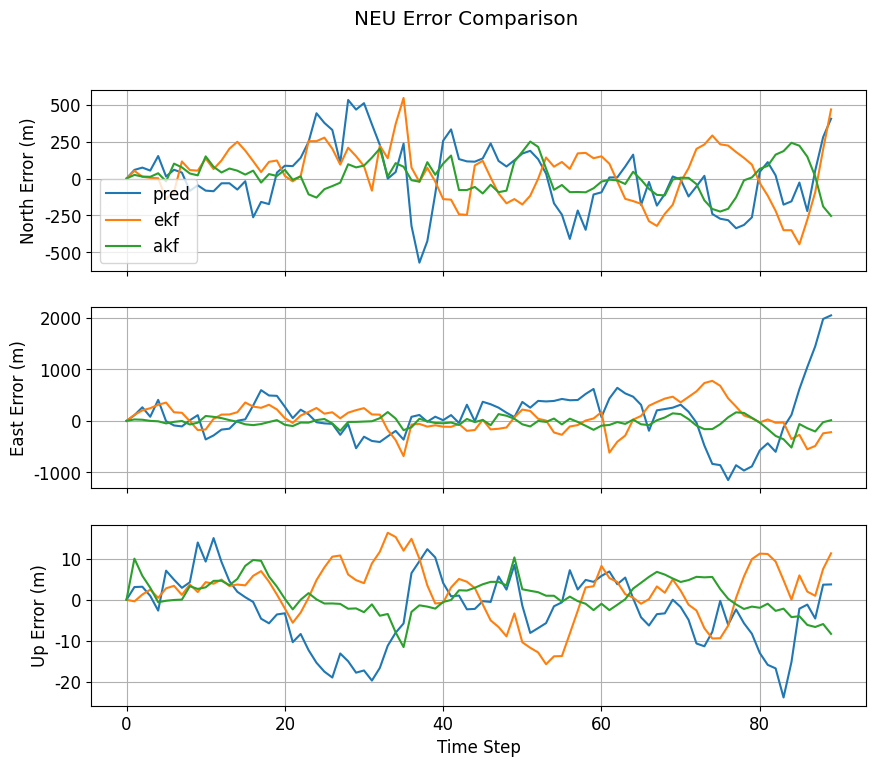

In [55]:
ref_col = df_N.columns[0]

algo_cols = df_N.columns[1:]

errors = {}

for col in algo_cols:
    if(col in exclude_columns):
        continue
    err = np.stack([
        df_N[col].values - df_N[ref_col].values,
        df_E[col].values - df_E[ref_col].values,
        df_U[col].values - df_U[ref_col].values
    ], axis=1)

    errors[col] = err

# ======================
# 画误差图
# ======================
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

directions = ['North Error (m)', 'East Error (m)', 'Up Error (m)']

for i in range(3):
    for label, err in errors.items():
        axs[i].plot(err[:, i], label=label)

    axs[i].set_ylabel(directions[i])
    axs[i].grid(True)

axs[-1].set_xlabel('Time Step')
axs[0].legend()
fig.suptitle('NEU Error Comparison')

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

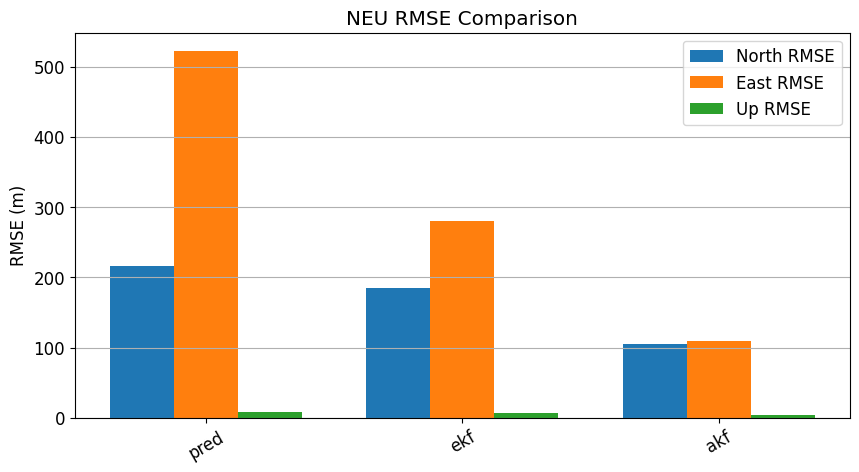

In [56]:
ref_col = df_N.columns[0]

algo_cols = df_N.columns[1:]

rmse = {}

for col in algo_cols:
    if col in exclude_columns:
        continue

    diff_n = df_N[col].values - df_N[ref_col].values
    diff_e = df_E[col].values - df_E[ref_col].values
    diff_u = df_U[col].values - df_U[ref_col].values

    rmse[col] = [
        np.sqrt(np.mean(diff_n ** 2)),
        np.sqrt(np.mean(diff_e ** 2)),
        np.sqrt(np.mean(diff_u ** 2))
    ]
import numpy as np
import matplotlib.pyplot as plt

labels = list(rmse.keys())
vals = np.array(list(rmse.values()))  # (N, 3)

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - width, vals[:, 0], width, label='North RMSE')
plt.bar(x,         vals[:, 1], width, label='East RMSE')
plt.bar(x + width, vals[:, 2], width, label='Up RMSE')

plt.xticks(x, labels, rotation=30)
plt.ylabel("RMSE (m)")
plt.title("NEU RMSE Comparison")
plt.grid(True, axis='y')
plt.legend()

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

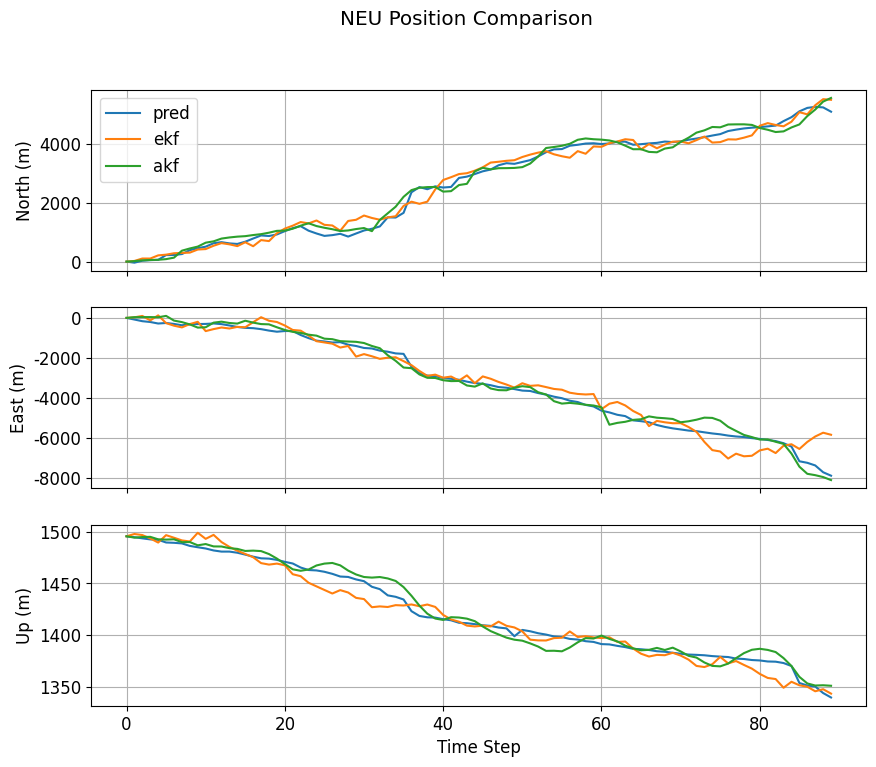

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

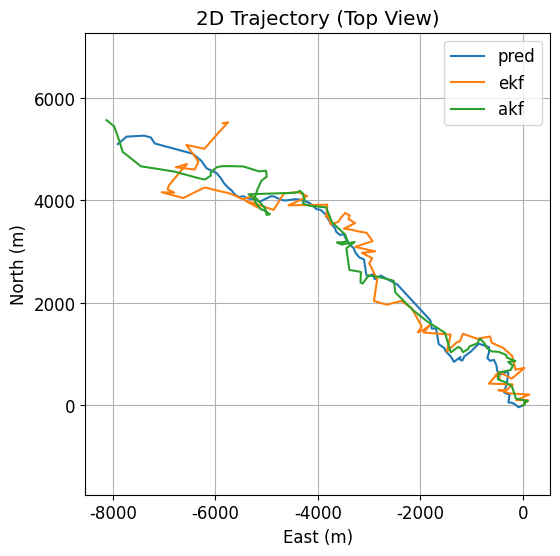

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

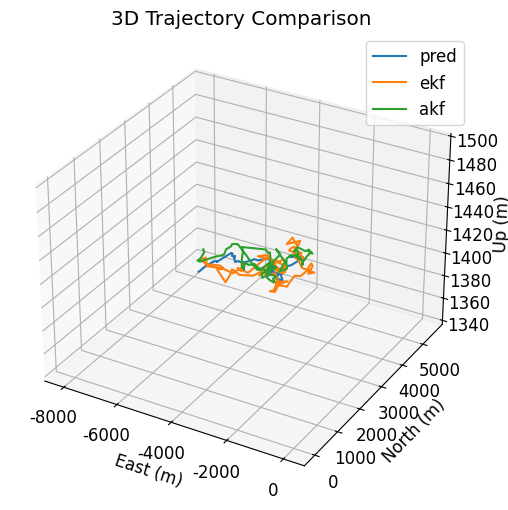

In [57]:
# 样条插值法

import numpy as np
from scipy.interpolate import CubicSpline

def spline_interpolate_trajectory(traj, num_points=200):
    """
    对单条3D轨迹做样条插值

    Parameters:
        traj: (N, 3) 原始轨迹
        num_points: 插值后点数

    Returns:
        traj_interp: (num_points, 3)
    """
    traj = np.asarray(traj)

    n = traj.shape[0]
    t = np.arange(n)  # 参数轴（也可以换成真实时间）

    # 分别对 x/y/z 做三次样条
    cs_x = CubicSpline(t, traj[:, 0])
    cs_y = CubicSpline(t, traj[:, 1])
    cs_z = CubicSpline(t, traj[:, 2])

    t_new = np.linspace(0, n - 1, num_points)

    traj_interp = np.stack([
        cs_x(t_new),
        cs_y(t_new),
        cs_z(t_new)
    ], axis=1)

    return traj_interp

trajectories_interp = []

# for col in cols:
#     if(col in exclude_columns):
#         continue
#     traj = np.stack([
#         df_N[col].values,
#         df_E[col].values,
#         df_U[col].values
#     ], axis=1)
#
#     trajectories.append(traj)
#     labels.append(col)
# plot_neu_and_3d(trajectories, labels)
for traj in trajectories:
    traj_smooth = spline_interpolate_trajectory(traj, num_points=300)
    trajectories_interp.append(traj_smooth)
plot_neu_and_3d(trajectories, labels)